# ERA5 Zarr Archive Analysis and Visualization

### Overview
This Notebook visualizes total precipitation at Lake Touson Alabama from 1940 - 2025. ERA5 provides hourly global reanalysis data on single levels, allowing us to examine near surface wather condirions in detail.  

By completing this notebook, you’ll learn how to:

- Load and explore Zarr datasets using xarray and pandas

- Subset regional climate data using latitude/longitude bounds

- Visualize precipitation trends, anomalies, and century-scale distributions

# Imports

In [14]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#### Load ERA5 dataset

In [15]:
ds = xr.open_dataset(
    "https://data.earthdatahub.destine.eu/era5/reanalysis-era5-single-levels-monthly-means-v0.zarr",
    storage_options={"client_kwargs":{"trust_env":True}},
    chunks={},
    engine="zarr",
)
ds

<xarray.Dataset> Size: 34GB
Dimensions:     (valid_time: 1030, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-10-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    surface     float64 8B ...
Data variables:
    d2m         (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(120, 256, 256), meta=np.ndarray>
    msl         (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(120, 256, 256), meta=np.ndarray>
    sp          (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(120, 256, 256), meta=np.ndarray>
    sst         (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(120, 256, 256), meta=np.ndarray>
    t2m         (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(120, 256, 256), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(120, 256, 256), meta=np.ndarray>
    u10         (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(120, 256, 256), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 4GB dask.array<chunksize=(120, 256, 256), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-10-30T04:46 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

### Select the “total precipitation” variable

In [16]:
tp = ds["tp"]  # units: m 
print(f"Longitude range: {ds.longitude.min().values} -> {ds.longitude.max().values}")
print(f"Latidue range: {ds.latitude.min().values} -> {ds.latitude.max().values}")

Longitude range: 0.0 -> 359.75
Latidue range: -90.0 -> 90.0


### Subset Lake Touson Alabama

In [17]:
lat_bnds = [33, 32]    
lon_bnds = [272, 273]  
al_tp = tp.sel(latitude=slice(lat_bnds[0], lat_bnds[1]),
               longitude=slice(lon_bnds[0], lon_bnds[1]))
al_tp.shape

(1030, 5, 5)

### Calculating spatial average over the region

In [18]:
al_tp_mean = al_tp.mean(dim=["latitude", "longitude"])

### Convert units from m → mm)  

In [19]:
al_tp_mm = al_tp_mean * 1000.0  # now mm per month ( original was m/month)  
df = al_tp_mm.to_pandas()

We are using the variable tp (total precipitation) for the state of Alabama, approximated by a latitude‐longitude box. Because the dataset provides monthly means, it is important to interpret the values as area‐averaged grid‐cell values, not point station data.

### Create a DataFrame for plotting

In [20]:
df = al_tp_mm.to_pandas()
df
df.index = pd.to_datetime(df.index)  # should already be monthly

### Now lets create a some plots to visualize the data. We'll start with a plotting the full timeseries ...

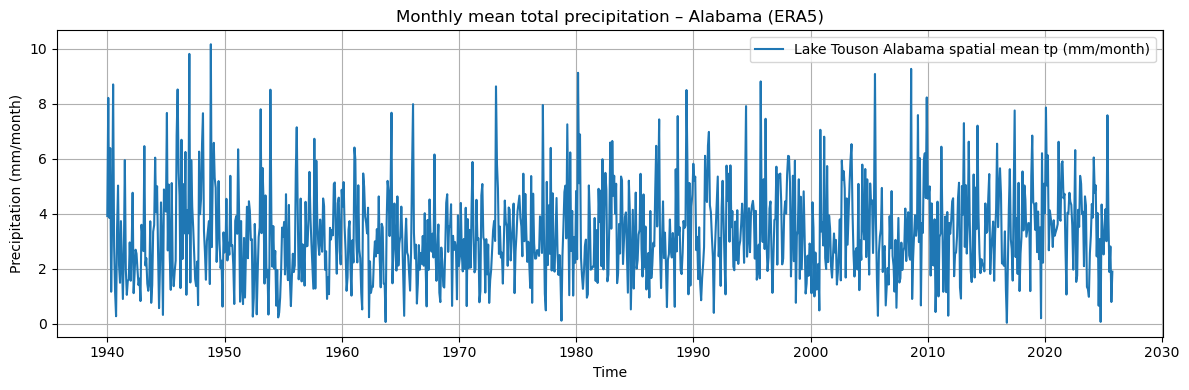

In [21]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df.values, label="Lake Touson Alabama spatial mean tp (mm/month)")
plt.xlabel("Time")
plt.ylabel("Precipitation (mm/month)")
plt.title("Monthly mean total precipitation – Alabama (ERA5)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

The plot above shows the monthly mean total precipitation in Alabama from the ERA5 monthly means dataset (in mm/month) for the defined latitude/longitude region.

#### Compute Seasonal Cycle & Trend

In [22]:
clim = df.groupby(df.index.month).mean()

### Plot Climatology

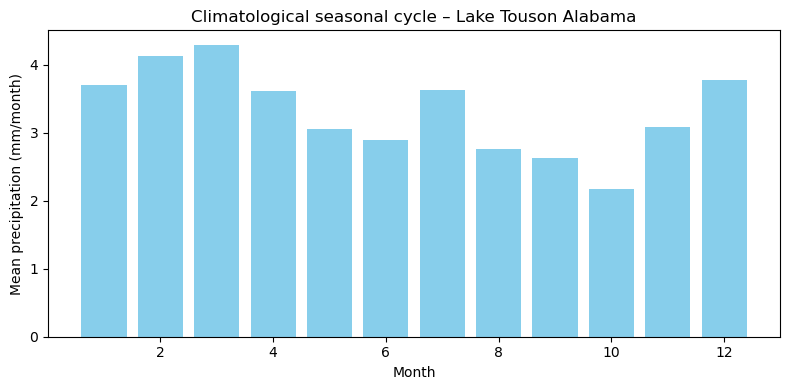

In [23]:
plt.figure(figsize=(8,4))
plt.bar(range(1,13), clim.values.squeeze(), color="skyblue")
plt.xlabel("Month")
plt.ylabel("Mean precipitation (mm/month)")
plt.title("Climatological seasonal cycle – Lake Touson Alabama")
plt.tight_layout()
plt.show()

### Compute trend (e.g., linear regression)

In [24]:
# Compute trend (e.g., linear regression)
import statsmodels.api as sm

### Prepare data for trend: convert time to numeric

In [25]:
t = np.arange(len(df))
y = df.values.squeeze()
X = sm.add_constant(t)
model = sm.OLS(y, X, missing='drop').fit()
trend_mm_per_month = model.params[1]
print(f"Linear trend: {trend_mm_per_month:.4f} mm/month per month => {trend_mm_per_month*12:.2f} mm/year")

Linear trend: 0.0005 mm/month per month => 0.01 mm/year


### Plot detrended time series with trend line

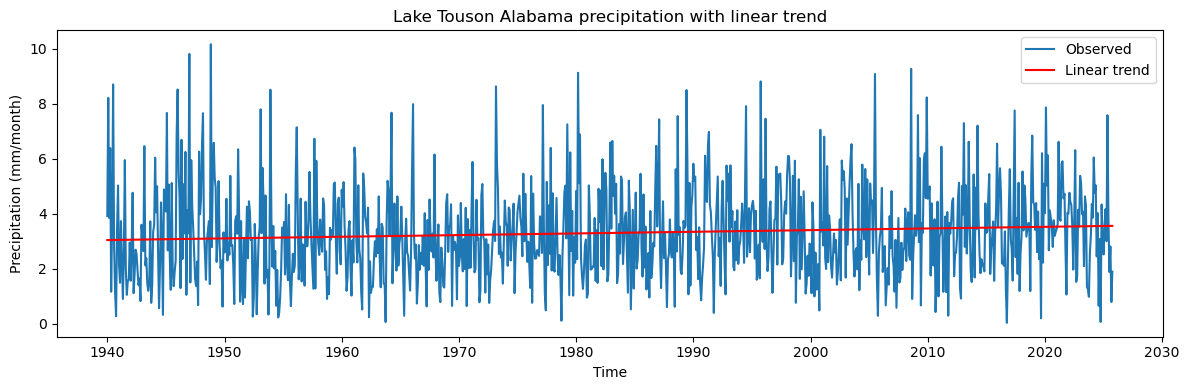

In [26]:
plt.figure(figsize=(12,4))
plt.plot(df.index, y, label="Observed")
plt.plot(df.index, model.params[0] + model.params[1]*t, color='red', label="Linear trend")
plt.xlabel("Time")
plt.ylabel("Precipitation (mm/month)")
plt.title("Lake Touson Alabama precipitation with linear trend")
plt.legend()
plt.tight_layout()
plt.show()

#### The bar chart shows the average monthly precipitation for each month of the year, revealing how wetter and drier months alternate.

#### The dataset shows a clear seasonal cycle: certain months (likely late winter to spring) tend to have higher precipitation, while others (summer/fall) may be relatively lower.